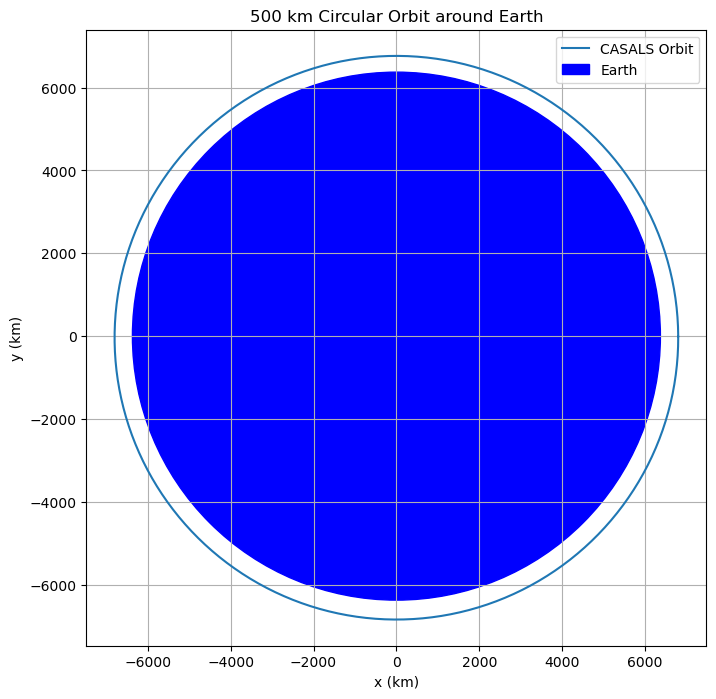

In [43]:
'''Orbit Relative to Earth
Row 21: The useful information is that it takes ~5590 secs to complete an orbit around earth'''

import numpy as np
import matplotlib.pyplot as plt

# Constants
G = 6.67430e-11        # m^3 kg^-1 s^-2
M_earth = 5.972e24     # kg
R_earth = 6371e3       # m
altitude = 430e3       # m
r_orbit = R_earth + altitude

# Initial position and velocity
r0 = np.array([r_orbit, 0])
v0 = np.array([0, np.sqrt(G * M_earth / r_orbit)])  # circular velocity

# Time settings
dt = 10  # seconds
num_steps = 559  # ~1.55 hours total simulated time for a full orbit

# Allocate arrays
r = np.zeros((num_steps, 2))
v = np.zeros((num_steps, 2))
r[0], v[0] = r0, v0

# Gravity function
def gravity(pos):
    r_mag = np.linalg.norm(pos)
    return -G * M_earth * pos / r_mag**3

# Integrate with Euler method
for i in range(num_steps - 1):
    a = gravity(r[i])
    v[i + 1] = v[i] + a * dt
    r[i + 1] = r[i] + v[i + 1] * dt

# Plotting
plt.figure(figsize=(8, 8))
plt.plot(r[:, 0] / 1e3, r[:, 1] / 1e3, label='CASALS Orbit')
earth = plt.Circle((0, 0), R_earth / 1e3, color='blue', label='Earth')
plt.gca().add_patch(earth)
plt.xlabel('x (km)')
plt.ylabel('y (km)')
plt.title('500 km Circular Orbit around Earth')
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()

In [44]:
'''Calculate SC velocity on ground'''
# Constants
G = 6.67430e-11  # m^3/kg/s^2
M_earth = 5.97219e24  # kg
R_earth = 6371e3  # m
altitude = 500e3  # m
c = 299792458  # speed of light in m/s

# Orbital radius
r = R_earth + altitude

# Circular orbital velocity 𝑣 = √𝐺𝑀/r
v = np.sqrt(G * M_earth / r)

# Relative velocity on earth, or Ground speed, ve = v*R_earth/r
ve = v*R_earth/r

# Print results
print(f"Circular orbital velocity at 500 km altitude: {v:.2f} m/s or {v/1e3:.2f} km/s")
print(f"Ground Speed:                                 {ve:.2f} m/s or {ve/1e3:.2f} km/s")

Circular orbital velocity at 500 km altitude: 7616.57 m/s or 7.62 km/s
Ground Speed:                                 7062.32 m/s or 7.06 km/s


In [45]:
''' With the ground velocity evaluated, we estimate the laser rep rate '''

ve=7062.32             #Ground speed if SC 
GSD=6                  #Ground Sample Distance in m
Swath_width=1000       #in m

# Calculate Rep Rate
Number_spot=Swath_width/GSD
RepRate=ve/(GSD/Number_spot)

# Print results
print(f" #Spots to cover 1km swath: {Number_spot:.0f}")
print(f" Rep Rate:                  {RepRate*1e-3:.3f} kHz")

 #Spots to cover 1km swath: 167
 Rep Rate:                  196.176 kHz


In [46]:
'''Based on rep rate and laser power, let's eavlaute some parameters for the laser system '''
RepRate = 196176                   # Rep Rate
pulse_energy_J = 1.5e-4            # Energy per pulse in joules

# calculate power output
Laser_output_power=RepRate*pulse_energy_J

# Pulse Peak Power evaluated as = 150µJ/2ns
PeakPower=150e-6/2e-9

# calculate input power to laser assuming system efficiency of 15%
Laser_input_power=Laser_output_power*100/15

# calculate thermal dissipation from laser assuming system efficiency of 15%
Laser_thermal_dissipation=Laser_input_power-Laser_output_power

print(f" Laser Output Power: {Laser_output_power:.2f} W")
print(f" Peak Power:         {150e-6/2e-9/1e3:.2f} kW")
print(f" Laser Input Power:  {Laser_input_power:.2f} W")
print(f" Laser dissipation:  {Laser_thermal_dissipation:.2f} W")

 Laser Output Power: 29.43 W
 Peak Power:         75.00 kW
 Laser Input Power:  196.18 W
 Laser dissipation:  166.75 W


In [47]:
''' More laser Output characteristics parameters '''

# calculate laser duty cycle based on rep rate and pulse duration
Duty_cycle=100*RepRate*2e-9

# calculate gap between pulse
Pulse_time_with_gap=1/RepRate

# Calculate distances for the pulse and between two pulses
distance_2ns=2e-9*c
Pulse_gap_m=(Pulse_time_with_gap*1e9-2)*1e-9*c

print(f" Duty Cycle:                     {Duty_cycle:.4f} %")
print(f" Gap between pulse:              {Pulse_time_with_gap*1e9:.2f} ns")
print(f" True gap between 2ns pulse:     {Pulse_time_with_gap*1e9-2:.2f} ns")
print(f" pulse travel distance:          {distance_2ns:.2f} m")
print(f" distance gap between 2ns pulse: {Pulse_gap_m/1e3:.3f} km")

 Duty Cycle:                     0.0392 %
 Gap between pulse:              5097.46 ns
 True gap between 2ns pulse:     5095.46 ns
 pulse travel distance:          0.60 m
 distance gap between 2ns pulse: 1.528 km


In [48]:
###### Waveform CASALS Data Rate Calculation

# It has two parts: 1. to recreate the waveform of received pulse with sufficient background and 2. evaluate background at low resolution during off pulse period

# Default Parameters
#RepRate = 196176          # Hz (based on calculations above, effectively = Vsc*Swath/(GSD^2)
samples_per_waveform = 100 # samples (This to create a gaussian Rx pulse waveform with sufficient background details: asked John-John suggested 100, should give 6-8 points within peak FWHM)
bits_per_sample = 16       # bits per "Overview of CASALS FPGA software development_17Oct2023 v4_changes 13sept2024", chart 8; John agrees on 12-16
num_channels = 64          # channels (John says the 64x4 or 64x2 pixed detector output will be binned to get a 64x1 output from the detector)
compression_factor = 2     # Compression Factor of 2x: scope for further improvement to be explored
atm_background_binning_points = 5090 # binning points in off pulse period (recall there is 5098 ns gap between each 2 nm pulse, considering 16 bits of data pint and a single string data from all pixels, 10ns each: ask John)
bits_per_background_point = 16       # Bit Depth for each 1ns separated point of the backgorund assuming 1 binned output from all pixels on detector: check with John

# Caluclations
data_rate_bps = RepRate * samples_per_waveform * bits_per_sample * num_channels / compression_factor # bits per sec
data_rate_MBps = data_rate_bps / (8 * 10**6)  # Convert bits per second to Megabytes per sec
data_rate_atm_background_bps = RepRate * atm_background_binning_points * bits_per_background_point / compression_factor # bits per sec
data_rate_atm_background_MBps = data_rate_atm_background_bps / (8 * 10**6) # Megabytes per sec


# Display Results
print("\n=== Waveform CASALS Data Rate Results ===")
print(f"Data Rate:            {data_rate_bps:.4e} bits/s")
print(f"Data Rate:            {data_rate_MBps:.2f} MB/s")
print(f"Atm Background Data Rate: {data_rate_atm_background_bps:.2e} bits/s")
print(f"Atm Background Data Rate: {data_rate_atm_background_MBps:.2f} MB/s")


=== Waveform CASALS Data Rate Results ===
Data Rate:            1.0044e+10 bits/s
Data Rate:            1255.53 MB/s
Atm Background Data Rate: 7.99e+09 bits/s
Atm Background Data Rate: 998.54 MB/s


In [53]:
# Grating calculation using a grating with 1500 LPM (small angle approximation)
'''
d=1e-3/LPM=6.67×10^−7)

Assuming small angle approximation as follows:
d.sin(𝜃)=𝜆
For fixed d, taking differential, d.cos(𝜃)Δ𝜃 = Δ𝜆 => Δ𝜃 ≈ Δ𝜆/d.cos(𝜃)

Δλ=14nm=1.4×10^−8 m
𝜃≈small => cos(θ)≈1
d=6.67×10^−7 m

Δ𝜃 ≈ Δ𝜆/d.cos(𝜃)
Δθ≈ 1.4×10^−8/6.67×10^−7 ≈ 0.021 radians ≈ 21 mrad

Beam Spread=h⋅Δθ=5×10^5*0.021≈10.5km
'''

import numpy as np
import math
import matplotlib.pyplot as plt

# Constants
c = 299792458  # speed of light in m/s

# Input Parameters
grating_lpm = 1503.76                  # lines per mm
center_wavelength_nm = 1040            # central wavelength (nm)
wavelength_span_nm = 14                # total span (nm)
altitude_km = 500                      # observation altitude (km)

# Derived Values
d = 1 / (grating_lpm * 1e3)            # groove spacing in meters
lambda_center = center_wavelength_nm * 1e-9
delta_lambda = wavelength_span_nm * 1e-9
altitude_m = altitude_km * 1e3

# Angular divergence (small angle approx)
delta_theta_rad = delta_lambda / d

# Ground footprint
footprint_m = altitude_m * delta_theta_rad
footprint_km = footprint_m / 1000

#Assuming the effective span to be wihtin 2/3 of the footprint, the effective span size:
span_km=footprint_km*(1-2*1/math.e**2)


# Print summary
print("=== Grating Divergence Calculations ===")
print(f"Grating:                      {grating_lpm} lines/mm")
print(f"Wavelength span:              {wavelength_span_nm} nm around {center_wavelength_nm} nm")
print(f"Altitude:                     {altitude_km} km")
print(f"Angular divergence:           {delta_theta_rad*1e3:.2f} mrad or {np.degrees(delta_theta_rad):.2f} degrees")
print(f"Beam footprint on ground:     {footprint_km:.2f} km")
print(f"Effective Beam span on ground:{span_km:.2f} km")

=== Grating Divergence Calculations ===
Grating:                      1503.76 lines/mm
Wavelength span:              14 nm around 1040 nm
Altitude:                     500 km
Angular divergence:           21.05 mrad or 1.21 degrees
Beam footprint on ground:     10.53 km
Effective Beam span on ground:7.68 km


In [54]:
'''same calculation for 4.5 km'''

import numpy as np
import math
import matplotlib.pyplot as plt

# Constants
c = 299792458  # speed of light in m/s
plane_speed= 115 # speed of plane in m/s 

# Input Parameters
grating_lpm = 1503.76                  # lines per mm
center_wavelength_nm = 1040            # central wavelength (nm)
wavelength_span_nm = 14                # total span (nm)
altitude_km = 4.5                      # observation altitude (km)

# Derived Values
d = 1 / (grating_lpm * 1e3)            # groove spacing in meters
lambda_center = center_wavelength_nm * 1e-9
delta_lambda = wavelength_span_nm * 1e-9
altitude_m = altitude_km * 1e3

# Angular divergence (small angle approx)
delta_theta_rad = delta_lambda / d

#Assuming the effective/useful divergence to be leaving 1/e^2 of the beam span on both sides of the footprint. 
# The effective divergence:
delta_theta_rad_eff=delta_theta_rad*(1-2*1/math.e**2)

# Ground footprint
footprint_m = altitude_m * delta_theta_rad
footprint_km = footprint_m / 1000

#Assuming the effective span to be leaving 1/e^2 of the beam span on both sides of the footprint. 
# The effective span size:
span_km=footprint_km*(1-2*1/math.e**2)

# Frequency between each subsequent beam assuming 256 spots per swath relative to 1040±7nm
span_freq=(((c/1033e-9)-(c/1047e-9))/256)

# beam size on swath in km 
GSD_plane=span_km/256

# RepRate assuming 256 cross tracks with using GSD_plane above
RepRate_plane=(plane_speed/GSD_plane/1e3)*256

# Print summary
print("=== Calculations for 4.5km ===")
print(f"Grating:                      {grating_lpm} lines/mm")
print(f"Wavelength span:              {wavelength_span_nm} nm around {center_wavelength_nm} nm")
print(f"Altitude:                     {altitude_km} km")
print(f"Angular divergence:           {delta_theta_rad*1e3:.2f} mrad or {np.degrees(delta_theta_rad):.2f} degrees")
print(f"Effective Angular divergence: {delta_theta_rad_eff*1e3:.2f} mrad or {np.degrees(delta_theta_rad_eff):.2f} degrees")
print(f"Beam footprint on ground:     {footprint_km*1e3:.2f} m")
print(f"Effective Beam span on ground:{span_km*1e3:.2f} m")
print(f"Freq span:                    {span_freq/1e9:.2f} GHz")
print(f"Plane GSD:                    {GSD_plane*1e3:.3f} m")
print(f"Plane RepRate:                {RepRate_plane/1e3:.3f} kHz")

=== Calculations for 4.5km ===
Grating:                      1503.76 lines/mm
Wavelength span:              14 nm around 1040 nm
Altitude:                     4.5 km
Angular divergence:           21.05 mrad or 1.21 degrees
Effective Angular divergence: 15.35 mrad or 0.88 degrees
Beam footprint on ground:     94.74 m
Effective Beam span on ground:69.09 m
Freq span:                    15.16 GHz
Plane GSD:                    0.270 m
Plane RepRate:                109.077 kHz


In [51]:
'''This prints out the parameters from Guan's paper on Teams titled: 
Airborne Lidar Demonstration of the Concurrent Artificially-intelligent Spectrometry and Adaptive Lidar System (CASALS) for Swath Mapping from Space 
The paper is locaed in CASALS Team > General > Airplane Demo > CASALS airplane campaign paper'''

import pandas as pd
from tabulate import tabulate

# CASALS system parameters
parameters = [
    ['Center Wavelength', '1040 nm'],
    ['Wavelength Span', '14 nm'],
    ['Laser Sweep Rate', '4.5 kHz'],
    ['Number of Wavelengths per Sweep', '256'],
    ['Frequency Space Between Wavelengths', '14.6 GHz'],
    ['Angle Separation Between Wavelengths', '51.77 µRad'],
    ['Total Angular Span of 256 Wavelengths', '13.074 mRad'],
    ['Cross-Track Footprint Separation (4.5 km Alt)', '0.232 m'],
    ['Laser Spot Size (FWHM) (4.5 km Alt)', '0.233 m'],
    ['Along-Track Footprint Separation', '0.203 m'],
    ['Swath Width (256 Footprints)', '59.39 m'],
    ['Grating Lines per mm', '1500 lines/mm'],
    ['Airplane Speed', '115 m/s'],
    ['LiDAR Pulse Width', '2 ns'],
    ['LiDAR Pulse Peak Power', '723 W'],
    ['Transmitter Telescope Aperture', '10 cm'],
    ['Output Beam Quality (M²)', '1.1'],
    ['Total Transmitter Power', '0.222 W'],
    ['Number of Wavelengths per Sweep Used', '30'],
    ['Sweeps per Full Cycle (256 Wavelengths)', '8'],
    ['Start Pulse Detector Pulse Width', '10 ns'],
    ['Transmitter Optical Throughput', '90%']
]

# Create table using tabulate
table = tabulate(parameters, headers=['CASALS Parameter', 'Value'], tablefmt='fancy_grid')

# Print table
print(table)


╒═══════════════════════════════════════════════╤═══════════════╕
│ CASALS Parameter                              │ Value         │
╞═══════════════════════════════════════════════╪═══════════════╡
│ Center Wavelength                             │ 1040 nm       │
├───────────────────────────────────────────────┼───────────────┤
│ Wavelength Span                               │ 14 nm         │
├───────────────────────────────────────────────┼───────────────┤
│ Laser Sweep Rate                              │ 4.5 kHz       │
├───────────────────────────────────────────────┼───────────────┤
│ Number of Wavelengths per Sweep               │ 256           │
├───────────────────────────────────────────────┼───────────────┤
│ Frequency Space Between Wavelengths           │ 14.6 GHz      │
├───────────────────────────────────────────────┼───────────────┤
│ Angle Separation Between Wavelengths          │ 51.77 µRad    │
├───────────────────────────────────────────────┼───────────────┤
│ Total An

In [52]:
'''Note that the parameters from small angle scattering calculations and
Guan's paper are different but of similar order. The evaluations are likely 
based on similar approximations'''

import pandas as pd
from tabulate import tabulate

# LiDAR system parameters
parameters = [
    ['Center Wavelength', '1040 nm', '1040 nm'],
    ['Wavelength Span', '14 nm', '14 nm'],
    ['Laser Sweep Rate', '4.5 kHz', '109 kHz Reprate'],
    ['Number of Wavelengths per Sweep', '256', '256 assumed'],
    ['Frequency Space Between Wavelengths', '14.6 GHz', '15.16 GHz'],
    ['Angle Separation Between Wavelengths', '51.77 µRad', '59.96 µRad'],
    ['Total Angular Span of 256 Wavelengths', '13.074 mRad', '15.35 mRad'],
    ['Cross-Track Footprint Separation (4.5 km Alt)', '0.232 m', '0.270 m'],
    ['Laser Spot Size (FWHM) (4.5 km Alt)', '0.233 m', '0.270 m'],
    ['Along-Track Footprint Separation', '0.203 m', '0.203 assumed'],
    ['Swath Width (256 Footprints)', '59.39 m', '69.09 m'],
    ['Grating Lines per mm', '1500 lines/mm', '1500 lines/mm'],
    ['Airplane Speed', '115 m/s', '115 m/s assumed'],
    ['LiDAR Pulse Width', '2 ns', '- ns'],
    ['LiDAR Pulse Peak Power', '723 W', '- W'],
    ['Transmitter Telescope Aperture', '10 cm', '-'],
    ['Output Beam Quality (M²)', '1.1', '-'],
    ['Total Transmitter Power', '0.222 W', '- W'],
    ['Number of Wavelengths per Sweep Used', '30', '8x30=240 Discuss'],
    ['Sweeps per Full Cycle (256 Wavelengths)', '8', 'Discuss sweep mechanism'],
    ['Start Pulse Detector Pulse Width', '10 ns', '- ns'],
    ['Transmitter Optical Throughput', '90%', '-']
]

# Create table using tabulate
table = tabulate(parameters, headers=['Parameter', 'numbers from Manuscript', 'DKR calculations'], tablefmt='fancy_grid')

# Print table
print(table)


╒═══════════════════════════════════════════════╤═══════════════════════════╤═════════════════════════╕
│ Parameter                                     │ numbers from Manuscript   │ DKR calculations        │
╞═══════════════════════════════════════════════╪═══════════════════════════╪═════════════════════════╡
│ Center Wavelength                             │ 1040 nm                   │ 1040 nm                 │
├───────────────────────────────────────────────┼───────────────────────────┼─────────────────────────┤
│ Wavelength Span                               │ 14 nm                     │ 14 nm                   │
├───────────────────────────────────────────────┼───────────────────────────┼─────────────────────────┤
│ Laser Sweep Rate                              │ 4.5 kHz                   │ 109 kHz Reprate         │
├───────────────────────────────────────────────┼───────────────────────────┼─────────────────────────┤
│ Number of Wavelengths per Sweep               │ 256           